# 模型训练与优化



### python版本


In [ ]:
import sys
print("Python version")
print(sys.version)

Python version
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


### torch 与 cuda 版本

In [1]:
import torch
print("Torch version")
print(torch.__version__)
print("CUDA version")
print(torch.version.cuda)
print("CUDNN version")
print(torch.backends.cudnn.version())
print("Is CUDA available?")
print(torch.cuda.is_available())
print("Number of CUDA devices")
print(torch.cuda.device_count())
print("Current CUDA device")
print(torch.cuda.current_device())
print("CUDA device name")
print(torch.cuda.get_device_name(torch.cuda.current_device()))
print("CUDA device properties")
print(torch.cuda.get_device_properties(torch.cuda.current_device()))
import torchvision
print("Torchvision version: ", torchvision.__version__)
import torchaudio
print("Torchaudio version: ", torchaudio.__version__)

Torch version
2.9.1+cu126
CUDA version
12.6
CUDNN version
91002
Is CUDA available?
True
Number of CUDA devices
1
Current CUDA device
0
CUDA device name
NVIDIA GeForce RTX 4060 Laptop GPU
CUDA device properties
_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=2cf29042-2bfa-83b7-45dd-c591da8e061a, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)
Torchvision version:  0.24.1+cu126
Torchaudio version:  2.9.1+cpu


In [1]:
import torch
print("Torch version")
print(torch.__version__)
print("CUDA version")
print(torch.version.cuda)
print("CUDNN version")
print(torch.backends.cudnn.version())
print("Is CUDA available?")
print(torch.cuda.is_available())
print("Number of CUDA devices")
print(torch.cuda.device_count())
print("Current CUDA device")
print(torch.cuda.current_device())
print("CUDA device name")
print(torch.cuda.get_device_name(torch.cuda.current_device()))
print("CUDA device properties")
print(torch.cuda.get_device_properties(torch.cuda.current_device()))
import torchvision
print("Torchvision version: ", torchvision.__version__)
import torchaudio
print("Torchaudio version: ", torchaudio.__version__)

Torch version
2.3.1+cu121
CUDA version
12.1
CUDNN version
8907
Is CUDA available?
True
Number of CUDA devices
1
Current CUDA device
0
CUDA device name
NVIDIA GeForce RTX 4060 Laptop GPU
CUDA device properties
_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24)
Torchvision version:  0.18.1+cu121
Torchaudio version:  2.3.1+cu121


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm  # 用于进度条
import os

# --- 1. 配置 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 使用 GPU 如果可用
print(f"Using device: {device}")

cwd_dir = os.getcwd()
# 数据路径
data_dir = os.path.join(cwd_dir, r'sleep-edf\data')
train_X_path = os.path.join(data_dir, 'train', 'cache', 'X_resampled.npy')
train_y_path = os.path.join(data_dir, 'train', 'cache', 'y_resampled.npy')
val_X_path = os.path.join(data_dir, 'val', 'cache', 'X_resampled.npy')
val_y_path = os.path.join(data_dir, 'val', 'cache', 'y_resampled.npy')
test_X_path = os.path.join(data_dir, 'test', 'cache', 'X_resampled.npy')
test_y_path = os.path.join(data_dir, 'test', 'cache', 'y_resampled.npy')

print(train_X_path)

# 检查文件是否存在
for path in [train_X_path, train_y_path, val_X_path, val_y_path, test_X_path, test_y_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Data file not found: {path}")

# 超参数（你可以调整）
num_epochs = 50  # 训练轮数
batch_size = 64  # 批量大小
learning_rate = 0.001  # 学习率
num_classes = 5  # 睡眠阶段数 (W, N1, N2, N3, REM)
seq_len = 3000  # EEG 序列长度（假设你的 resampling 后是 3000）
model_save_path = os.path.join(data_dir + '/model/', 'best_model.pth')  # 保存最佳模型

# --- 2. 数据加载 ---
def load_data():
    train_X = np.load(train_X_path, allow_pickle=True).astype(np.float32)  # (n_train, 1, 3000)
    train_y = np.load(train_y_path, allow_pickle=True).astype(np.int64)   # (n_train,)
    val_X = np.load(val_X_path, allow_pickle=True).astype(np.float32)
    val_y = np.load(val_y_path, allow_pickle=True).astype(np.int64)
    test_X = np.load(test_X_path, allow_pickle=True).astype(np.float32)
    test_y = np.load(test_y_path, allow_pickle=True).astype(np.int64)
    return train_X, train_y, val_X, val_y, test_X, test_y

train_X, train_y, val_X, val_y, test_X, test_y = load_data()
print(f"Train data shape: {train_X.shape}, Train labels shape: {train_y.shape}")

# 转换为 TensorDataset 和 DataLoader
train_dataset = TensorDataset(torch.tensor(train_X), torch.tensor(train_y))
val_dataset = TensorDataset(torch.tensor(val_X), torch.tensor(val_y))
test_dataset = TensorDataset(torch.tensor(test_X), torch.tensor(test_y))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- 3. 定义模型 ---
class SleepStageCNNLSTM(nn.Module):
    def __init__(self, num_classes=5, seq_len=3000):
        super(SleepStageCNNLSTM, self).__init__()
        # CNN 部分：提取局部特征（卷积核大小 64, 步长 1）
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=64, stride=1, padding=0)  # 输出: (N, 32, 3000-63)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=8, stride=8)  # 下采样
        self.conv2 = nn.Conv1d(32, 64, kernel_size=32, stride=1, padding=0)  # 输出: (N, 64, ...)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=8, stride=8)
        
        # 计算卷积后的序列长度（取决于你的数据，这里假设 pool 后长度 ~3000/64/8/8 ≈ 7）
        # 你可以打印输入张量形状来确认
        conv_output_len = seq_len // (8 * 8)  # 粗略估算，实际可能不同
        
        # LSTM 部分：处理序列依赖
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True, dropout=0.5)
        
        # 全连接输出
        self.fc = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # x: (batch, 1, 3000)
        x = torch.relu(self.bn1(self.conv1(x)))  # (batch, 32, ...)
        x = self.pool1(x)  # (batch, 32, ...)
        x = torch.relu(self.bn2(self.conv2(x)))  # (batch, 64, ...)
        x = self.pool2(x)  # (batch, 64, seq_len_reduced)
        
        x = x.permute(0, 2, 1)  # LSTM 需要 (batch, seq, features) -> (batch, seq, 64)
        _, (h, _) = self.lstm(x)  # h: (num_layers, batch, hidden)
        x = h[-1]  # 取最后层的隐藏状态 (batch, 128)
        x = self.dropout(x)
        x = self.fc(x)  # (batch, 5)
        return x

model = SleepStageCNNLSTM(num_classes=num_classes, seq_len=seq_len).to(device)

# --- 4. 训练和验证函数 ---
def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_acc = 0.0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        with tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}") as tqdm_loader:
            for inputs, labels in tqdm_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)  # 移除 squeeze(1)！输入是 (batch, 1, 3000)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                tqdm_loader.set_postfix(loss=loss.item())
        
        # 验证
        val_acc, val_f1 = evaluate_model(model, val_loader)
        print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
        
        # 保存最佳模型（基于验证准确率）
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            print(f"Best model saved with Val Acc: {best_val_acc:.4f}")

def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)  # 同样移除 squeeze(1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

# --- 5. 训练过程 ---
print("Starting training...")
train_model(model, train_loader, val_loader)

# --- 6. 测试最终模型 ---
print("Loading best model for testing...")
model.load_state_dict(torch.load(model_save_path, weights_only=True))
test_acc, test_f1 = evaluate_model(model, test_loader)
print(f"Test Acc: {test_acc:.4f}, Test Macro F1: {test_f1:.4f}")

print("Training complete! Check 'best_model.pth' for saved model.")


Using device: cuda
d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\X_resampled.npy
Train data shape: (22944, 1, 3001), Train labels shape: (22944,)
Starting training...


Epoch 1/50:   0%|          | 0/359 [00:00<?, ?it/s]


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Loading data...


Epoch 1: 100%|██████████| 299/299 [00:05<00:00, 51.90it/s]



[Epoch 1] Loss: 1.1558 | Val Acc: 0.5000 | F1: 0.4984
Pred Distribution: Counter({np.int64(4): 633, np.int64(0): 550, np.int64(1): 392, np.int64(2): 348, np.int64(3): 297})
--- New Best Model Saved ---


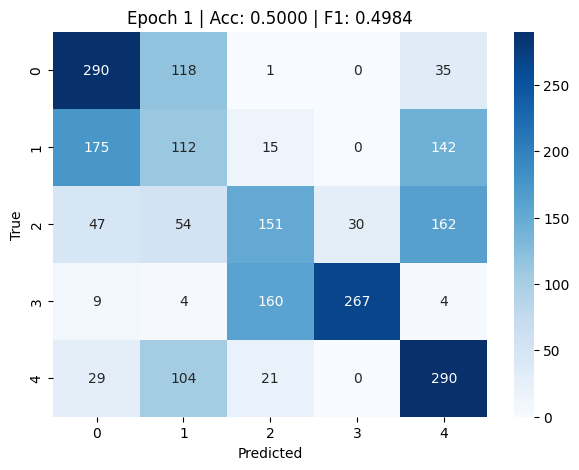

Epoch 2: 100%|██████████| 299/299 [00:05<00:00, 59.78it/s]



[Epoch 2] Loss: 0.9674 | Val Acc: 0.5671 | F1: 0.5442
Pred Distribution: Counter({np.int64(4): 713, np.int64(3): 510, np.int64(0): 465, np.int64(1): 300, np.int64(2): 232})
--- New Best Model Saved ---


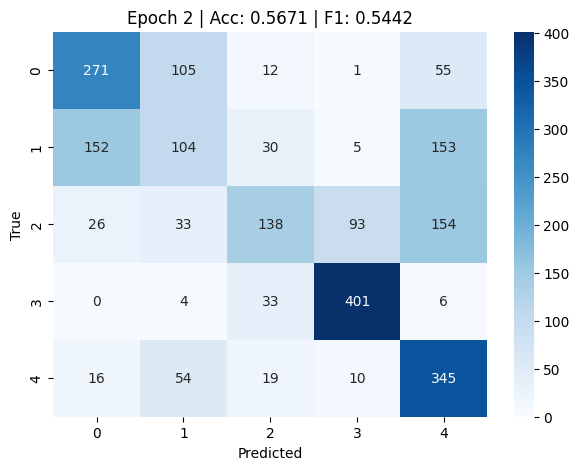

Epoch 3: 100%|██████████| 299/299 [00:04<00:00, 60.48it/s]



[Epoch 3] Loss: 0.9122 | Val Acc: 0.4311 | F1: 0.4028
Pred Distribution: Counter({np.int64(4): 1205, np.int64(2): 541, np.int64(3): 197, np.int64(0): 143, np.int64(1): 134})


Epoch 4: 100%|██████████| 299/299 [00:04<00:00, 61.69it/s]



[Epoch 4] Loss: 0.8813 | Val Acc: 0.4473 | F1: 0.3787
Pred Distribution: Counter({np.int64(3): 834, np.int64(2): 709, np.int64(0): 537, np.int64(1): 105, np.int64(4): 35})


Epoch 5: 100%|██████████| 299/299 [00:04<00:00, 60.55it/s]


...


[Epoch 10] Loss: 0.6967 | Val Acc: 0.4631 | F1: 0.4357
Pred Distribution: Counter({np.int64(0): 993, np.int64(1): 556, np.int64(3): 342, np.int64(2): 201, np.int64(4): 128})


Epoch 11: 100%|██████████| 299/299 [00:04<00:00, 62.50it/s]



[Epoch 11] Loss: 0.6740 | Val Acc: 0.2068 | F1: 0.0811
Pred Distribution: Counter({np.int64(0): 2152, np.int64(2): 59, np.int64(3): 9})


Epoch 12: 100%|██████████| 299/299 [00:04<00:00, 59.99it/s]



[Epoch 12] Loss: 0.6462 | Val Acc: 0.5928 | F1: 0.5796
Pred Distribution: Counter({np.int64(0): 691, np.int64(3): 479, np.int64(4): 362, np.int64(1): 349, np.int64(2): 339})
--- New Best Model Saved ---


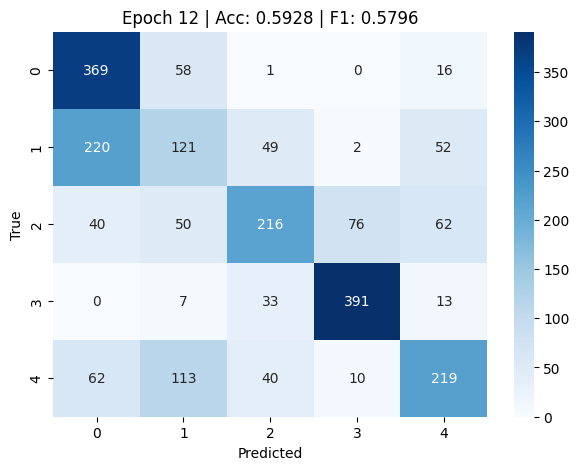

Epoch 13: 100%|██████████| 299/299 [00:04<00:00, 62.26it/s]



[Epoch 13] Loss: 0.6342 | Val Acc: 0.4829 | F1: 0.4830
Pred Distribution: Counter({np.int64(0): 701, np.int64(1): 526, np.int64(4): 396, np.int64(2): 352, np.int64(3): 245})


Epoch 14: 100%|██████████| 299/299 [00:04<00:00, 62.49it/s]



[Epoch 14] Loss: 0.6135 | Val Acc: 0.3176 | F1: 0.2510
Pred Distribution: Counter({np.int64(4): 1512, np.int64(2): 486, np.int64(1): 112, np.int64(3): 75, np.int64(0): 35})


Epoch 15: 100%|██████████| 299/299 [00:05<00:00, 59.70it/s]


...


[Epoch 48] Loss: 0.3551 | Val Acc: 0.5486 | F1: 0.5566
Pred Distribution: Counter({np.int64(1): 637, np.int64(2): 568, np.int64(3): 394, np.int64(4): 334, np.int64(0): 287})


Epoch 49: 100%|██████████| 299/299 [00:05<00:00, 59.77it/s]



[Epoch 49] Loss: 0.3527 | Val Acc: 0.5333 | F1: 0.5375
Pred Distribution: Counter({np.int64(2): 659, np.int64(1): 596, np.int64(3): 414, np.int64(0): 339, np.int64(4): 212})


Epoch 50: 100%|██████████| 299/299 [00:04<00:00, 60.50it/s]



[Epoch 50] Loss: 0.3514 | Val Acc: 0.5550 | F1: 0.5616
Pred Distribution: Counter({np.int64(1): 612, np.int64(2): 578, np.int64(3): 418, np.int64(4): 319, np.int64(0): 293})
Training finished.


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- 硬件与路径配置 ---
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'best_spectrogram_model.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 0.001
num_epochs = 50
seq_len = 1000 # 30秒缩放到1000点 

# --- 数据集类（加入标准化：极其关键） ---
class SleepDataset(Dataset):
    def __init__(self, X, y, augment=False):
        if X.ndim == 2:
            X = np.expand_dims(X, axis=1)
        
        # 转换为tensor
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化：让信号分布在0附近，有助于模型收敛
        mean = self.X.mean()
        std = self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            # 简单的噪声增强
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.01
        return x, self.y[idx]

# --- 新模型：基于频谱图的CNN ---
class SleepSpectrogramNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # 短时傅里叶变换的参数
        self.n_fft = 128    # 频率分辨率
        self.hop_length = 32 # 时间分辨率
        
        # 经过STFT后，1000个点的输入会变成 (Freq:65, Time:32) 左右的图像
        self.conv_net = nn.Sequential(
            # 第一层卷积
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU(), # ELU在信号处理中通常比ReLU更稳
            nn.MaxPool2d(kernel_size=2), # -> (32, 32, 16)
            
            # 第二层卷积
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2), # -> (64, 16, 8)
            
            # 第三层卷积
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 1)) # 压缩成 (128, 1, 1)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (Batch, 1, 1000)
        x_sq = x.squeeze(1) # (Batch, 1000)
        
        # 变换到频域 (Spectrogram)
        # return_complex=True 得到复数，然后用 abs 取振幅
        stft = torch.stft(x_sq, n_fft=self.n_fft, hop_length=self.hop_length, 
                          return_complex=True, 
                          window=torch.hann_window(self.n_fft).to(x.device))
        
        mag = torch.abs(stft) # (Batch, Freq_bins:65, Time_steps:32)
        mag = mag.unsqueeze(1) # 增加通道维 (Batch, 1, 65, 32)
        
        # 对数变换：信号能量通常跨度很大，取对数更利于CNN学习
        mag = torch.log1p(mag) 
        
        features = self.conv_net(mag)
        features = features.view(features.size(0), -1)
        out = self.fc(features)
        return out

# --- 通用评估函数 ---
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, f1, cm, all_preds

def print_confusion_matrix(cm, acc, f1, epoch):
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Epoch {epoch} | Acc: {acc:.4f} | F1: {f1:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    # 计算每个分类的准确率
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    print(f"Epoch {epoch} | Overall Acc: {acc:.4f} | F1: {f1:.4f}")
    print("Class-wise Accuracies:")
    for i, class_acc in enumerate(class_accuracies):
        print(f"  Class {i}: {class_acc:.4f}")

# --- 主训练流程 ---
if __name__ == "__main__":
    # 1. 加载数据
    def load_data(path):
        X = np.load(os.path.join(path, 'X_resampled.npy'))
        y = np.load(os.path.join(path, 'y_resampled.npy'))
        valid = (y != -1)
        return X[valid], y[valid]

    print("Loading data...")
    train_X, train_y = load_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_data(os.path.join(data_dir, 'val', 'cache'))
    test_X, test_y = load_data(os.path.join(data_dir, 'test', 'cache'))

    train_loader = DataLoader(SleepDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepDataset(val_X, val_y), batch_size=batch_size)
    test_loader = DataLoader(SleepDataset(test_X, test_y), batch_size=batch_size)

    # 2. 初始化模型与优化器
    model = SleepSpectrogramNet(num_classes=5).to(device)
    
    # 类别权重处理
    weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    # 3. 训练循环
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # 验证
        val_acc, val_f1, cm, preds = evaluate_model(model, val_loader)
        print(f"\n[Epoch {epoch+1}] Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"Pred Distribution: {Counter(preds)}")
        
        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            print("--- New Best Model Saved ---")
            print_confusion_matrix(cm, val_acc, val_f1, epoch+1)

    print("Training finished.")


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'best_sleep4_model.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数优化 ---
batch_size = 64
lr = 0.001
num_epochs = 50
num_classes = 4  # 调整为4分类

# --- 数据加载与标签合并逻辑 ---
def load_and_merge_data(path):
    print(f"Loading data from {path}...")
    X = np.load(os.path.join(path, 'X_resampled.npy'))
    y = np.load(os.path.join(path, 'y_resampled.npy'))
    
    valid = (y != -1)
    X, y = X[valid], y[valid]
    
    # 标签映射逻辑: 
    # 原始: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
    # 映射后: 0:W, 1:REM, 2:Light(N1+N2), 3:Deep(N3)
    y_new = np.zeros_like(y)
    for i in range(len(y)):
        if y[i] == 0:     y_new[i] = 0 # W
        elif y[i] == 4:   y_new[i] = 1 # REM
        elif y[i] == 1 or y[i] == 2: y_new[i] = 2 # Light
        elif y[i] == 3:   y_new[i] = 3 # Deep
    
    return X, y_new

# --- 数据集类 ---
class SleepDataset(Dataset):
    def __init__(self, X, y, augment=False):
        if X.ndim == 2:
            X = np.expand_dims(X, axis=1)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.3:
            x = x + torch.randn_like(x) * 0.01  # 注入微量噪声
        return x, self.y[idx]

# --- 进阶模型：高分辨率频谱 CNN ---
class SleepSpectroNet4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # 增加频域分辨率: n_fft=256 相比 128 能抓到更精细的频率特征
        self.n_fft = 256
        self.hop_length = 64 
        
        self.conv_net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(2), # 降采样
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 1, 3000)
        x_sq = x.squeeze(1)
        
        # STFT 变换
        stft = torch.stft(x_sq, n_fft=self.n_fft, hop_length=self.hop_length, 
                          return_complex=True, 
                          window=torch.hann_window(self.n_fft).to(x.device))
        
        mag = torch.abs(stft)
        mag = torch.log1p(mag).unsqueeze(1) # (Batch, 1, Freq, Time)
        
        feat = self.conv_net(mag)
        feat = feat.view(feat.size(0), -1)
        return self.fc(feat)

# --- 评估与可视化 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), confusion_matrix(all_l, all_p), all_p

def plot_cm(cm, acc, f1):
    plt.figure(figsize=(8, 6))
    labels = ['Wake', 'REM', 'Light', 'Deep']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
    plt.title(f"4-Class Sleep Stage | Acc: {acc:.4f}")
    plt.ylabel('True'); plt.xlabel('Pred')
    plt.show()

# --- 主程序 ---
if __name__ == "__main__":
    # 1. 加载并合并标签
    train_X, train_y = load_and_merge_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_and_merge_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepDataset(val_X, val_y), batch_size=batch_size)

    # 2. 初始化
    model = SleepSpectroNet4(num_classes=num_classes).to(device)
    
    # 计算平衡权重以处理样本不均
    weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

    # 3. 训练循环
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        t_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        acc, f1, cm, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Pred Dist: {Counter(preds)}")
        
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(">>> Best Model Updated")
            if acc > 0.65: # 只有准确率不错时才画图，减少干扰
                plot_cm(cm, acc, f1)

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading data from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache...
Loading data from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache...


Epoch 1: 100%|██████████| 299/299 [00:05<00:00, 56.36it/s]


Val Acc: 0.2392 | F1: 0.1381 | Pred Dist: Counter({np.int64(3): 1948, np.int64(2): 227, np.int64(1): 45})
>>> Best Model Updated


Epoch 2: 100%|██████████| 299/299 [00:04<00:00, 61.70it/s]


Val Acc: 0.4027 | F1: 0.3035 | Pred Dist: Counter({np.int64(0): 1296, np.int64(3): 890, np.int64(2): 34})
>>> Best Model Updated


...

Val Acc: 0.5658 | F1: 0.5644 | Pred Dist: Counter({np.int64(2): 1207, np.int64(3): 384, np.int64(1): 322, np.int64(0): 307})


Epoch 49: 100%|██████████| 299/299 [00:04<00:00, 60.62it/s]


Val Acc: 0.5757 | F1: 0.5463 | Pred Dist: Counter({np.int64(2): 1192, np.int64(0): 503, np.int64(3): 422, np.int64(1): 103})


Epoch 50: 100%|██████████| 299/299 [00:05<00:00, 58.02it/s]


Val Acc: 0.5707 | F1: 0.5455 | Pred Dist: Counter({np.int64(2): 1203, np.int64(0): 522, np.int64(3): 388, np.int64(1): 107})
Final Best Val Accuracy: 0.5820


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'best_sleep_context_model.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 0.001
num_epochs = 50
num_classes = 4

# --- 1. 核心优化：按患者构建时序数据 ---
def load_context_data(root_path):
    """
    遍历 patient_data 文件夹，在每个患者内部构建 (t-1, t, t+1) 的窗口
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    # 找到所有 X 文件
    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0 # W
        y_mapped[y_sub == 4] = 1 # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2 # Light
        y_mapped[y_sub == 3] = 3 # Deep
        
        # 构建 3-Epoch 窗口 (t-1, t, t+1)
        # 每个患者的数据独立处理，避免跨患者污染
        for i in range(1, len(x_sub) - 1):
            window = x_sub[i-1 : i+2] # 形状: (3, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类 ---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        # X shape: (N, 3, 3000)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化 (按通道独立或全局均可)
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.2:
            x = x + torch.randn_like(x) * 0.005 # 减小噪声强度
        return x, self.y[idx]

# --- 3. 进阶模型：3通道频谱 CNN ---
class SleepContextNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.n_fft = 256
        self.hop_length = 64 
        
        # 输入通道改为 3 (对应 t-1, t, t+1)
        self.conv_net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 3, 3000)
        batch_size = x.shape[0]
        
        # 对 3 个时间通道分别做 STFT
        specs = []
        for i in range(3):
            # 取出第 i 个通道: (Batch, 3000)
            x_single_channel = x[:, i, :].squeeze(1) # 增加 squeeze 确保维度正确
            
            # 使用 window
            win = torch.hann_window(self.n_fft).to(x.device)
            
            stft = torch.stft(
                x_single_channel, 
                n_fft=self.n_fft, 
                hop_length=self.hop_length, 
                return_complex=True, 
                window=win,
                center=True
            )
            
            mag = torch.abs(stft)
            specs.append(torch.log1p(mag).unsqueeze(1)) # (Batch, 1, Freq, Time)
        
        
        # 拼接后的形状: (Batch, 3, Freq, Time)
        x_spec = torch.cat(specs, dim=1)
        
        feat = self.conv_net(x_spec)
        feat = feat.view(batch_size, -1)
        return self.fc(feat)

# --- 评估函数 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), all_p

# --- 主程序 ---
if __name__ == "__main__":
    # 1. 加载上下文数据
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    # 2. 初始化模型
    model = SleepContextNet(num_classes=num_classes).to(device)
    
    # 类别权重处理
    weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

    # 3. 训练循环
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        acc, f1, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {Counter(preds)}")
        
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(">>> Best Model Saved")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 718.35it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 173/173 [00:03<00:00, 54.49it/s, loss=0.82] 


Val Acc: 0.3142 | F1: 0.3489 | Dist: Counter({np.int64(0): 793, np.int64(1): 194, np.int64(3): 172, np.int64(2): 149})
>>> Best Model Saved


...

Val Acc: 0.6827 | F1: 0.6444 | Dist: Counter({np.int64(2): 645, np.int64(0): 322, np.int64(3): 200, np.int64(1): 141})


Epoch 49: 100%|██████████| 173/173 [00:02<00:00, 68.88it/s, loss=0.609]


Val Acc: 0.6154 | F1: 0.6094 | Dist: Counter({np.int64(2): 505, np.int64(1): 346, np.int64(0): 254, np.int64(3): 203})


Epoch 50: 100%|██████████| 173/173 [00:02<00:00, 67.90it/s, loss=0.452]


Val Acc: 0.6315 | F1: 0.6195 | Dist: Counter({np.int64(2): 522, np.int64(0): 337, np.int64(1): 247, np.int64(3): 202})
Final Best Val Accuracy: 0.6972


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011501.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 0.001
num_epochs = 100
num_classes = 4

# --- 1. 核心优化：按患者构建时序数据 ---
def load_context_data(root_path):
    """
    遍历 patient_data 文件夹，在每个患者内部构建 (t-1, t, t+1) 的窗口
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    # 找到所有 X 文件
    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0 # W
        y_mapped[y_sub == 4] = 1 # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2 # Light
        y_mapped[y_sub == 3] = 3 # Deep
        
        # 构建 3-Epoch 窗口 (t-1, t, t+1)
        # 每个患者的数据独立处理，避免跨患者污染
        for i in range(1, len(x_sub) - 1):
            window = x_sub[i-1 : i+2] # 形状: (3, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类 ---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        # X shape: (N, 3, 3000)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化 (按通道独立或全局均可)
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.2:
            x = x + torch.randn_like(x) * 0.005 # 减小噪声强度
        return x, self.y[idx]

# --- 3. 进阶模型：3通道频谱 CNN ---
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # 保持输入输出通道一致
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.elu = nn.ELU()

    def forward(self, x):
        # 这里的 x 必须已经是 out_channels 维度的
        return self.elu(x + self.conv(x))

class SleepContextNetV2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.n_fft = 256
        self.hop_length = 64 
        
        # 1. 第一层：将 3 通道转为 32 通道
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.layer1 = ResidualBlock(32, 32)
        self.pool1 = nn.MaxPool2d(2)
        
        # 2. 第二层：升维到 64，再做残差
        self.trans2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1),
            nn.BatchNorm2d(64),
            nn.ELU()
        )
        self.layer2 = ResidualBlock(64, 64)
        self.pool2 = nn.MaxPool2d(2)
        
        # 3. 第三层：升维到 128，再做残差
        self.trans3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ELU()
        )
        self.layer3 = ResidualBlock(128, 128)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # STFT 部分核心保持一致
        batch_size = x.shape[0]
        specs = []
        win = torch.hann_window(self.n_fft).to(x.device)
        for i in range(3):
            xi = x[:, i, :].squeeze(1)
            stft = torch.stft(xi, n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = torch.abs(stft)
            specs.append(torch.log1p(mag).unsqueeze(1))
        
        x = torch.cat(specs, dim=1) # (B, 3, F, T)

        # 特征提取流程
        x = self.stem(x)
        x = self.layer1(x)
        x = self.pool1(x)
        
        x = self.trans2(x) # 先升维到 64
        x = self.layer2(x) # 此时输入是 64，ok
        x = self.pool2(x)
        
        x = self.trans3(x) # 先升维到 128
        x = self.layer3(x) # 此时输入是 128，ok
        
        x = self.avgpool(x).view(batch_size, -1)
        return self.fc(x)


# --- 评估函数 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), all_p

# --- 主程序 ---
if __name__ == "__main__":
    # 1. 加载上下文数据
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    # 2. 初始化模型
    model = SleepContextNetV2(num_classes=num_classes).to(device)
    
    # 类别权重处理
    weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    # 损失函数
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device),
        label_smoothing=0.1  
    )

    
    # 修改优化器和调度器
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) # 改用 AdamW
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


    # 3. 训练循环
    best_acc = 0
    patience = 10
    counter = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        acc, f1, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {Counter(preds)}")
        
        scheduler.step() # 如果用余弦退火，每轮停一次
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            counter = 0 # 重置
            print(f">>> New Best: {best_acc:.4f}")
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 706.25it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 173/173 [00:07<00:00, 21.74it/s, loss=1.15] 


Val Acc: 0.3647 | F1: 0.3892 | Dist: Counter({np.int64(3): 496, np.int64(1): 383, np.int64(0): 259, np.int64(2): 170})
>>> New Best: 0.3647


...

Val Acc: 0.6208 | F1: 0.6176 | Dist: Counter({np.int64(2): 454, np.int64(0): 350, np.int64(1): 284, np.int64(3): 220})


Epoch 25: 100%|██████████| 173/173 [00:07<00:00, 23.46it/s, loss=0.768]


Val Acc: 0.4121 | F1: 0.4497 | Dist: Counter({np.int64(3): 605, np.int64(0): 365, np.int64(1): 170, np.int64(2): 168})


Epoch 26: 100%|██████████| 173/173 [00:07<00:00, 23.44it/s, loss=1.12] 


Val Acc: 0.6651 | F1: 0.6263 | Dist: Counter({np.int64(2): 578, np.int64(0): 340, np.int64(3): 287, np.int64(1): 103})
Early stopping at epoch 25
Final Best Val Accuracy: 0.6774


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011501.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 0.001
num_epochs = 100
num_classes = 4

# --- 1. 核心优化：按患者构建时序数据 ---
def load_context_data(root_path):
    """
    遍历 patient_data 文件夹，在每个患者内部构建 (t-1, t, t+1) 的窗口
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    # 找到所有 X 文件
    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0 # W
        y_mapped[y_sub == 4] = 1 # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2 # Light
        y_mapped[y_sub == 3] = 3 # Deep
        
        # 构建 3-Epoch 窗口 (t-1, t, t+1)
        # 每个患者的数据独立处理，避免跨患者污染
        for i in range(1, len(x_sub) - 1):
            window = x_sub[i-1 : i+2] # 形状: (3, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类 ---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        # X shape: (N, 3, 3000)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化 (按通道独立或全局均可)
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.2:
            x = x + torch.randn_like(x) * 0.005 # 减小噪声强度
        return x, self.y[idx]

# --- 3. 模型：3通道频谱 CNN ---
class SEBlock(nn.Module):
    """通道注意力机制：让模型学会关注重要的频率通道"""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)
class SleepStageNetV3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # 提高 n_fft 以获得更好的频率分辨率 (针对 0.5-40Hz)
        self.n_fft = 512 
        self.hop_length = 64
        
        # 初始层
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        
        # Layer 1: 提取基础频率特征
        self.layer1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            SEBlock(64) # 加入注意力
        )
        
        # Layer 2: 提取高阶组合特征
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.MaxPool2d(2),
            SEBlock(128)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), # 增加 BN 层防止全连接层崩溃
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        batch_size = x.shape[0]
        # 频谱转换优化
        specs = []
        win = torch.hann_window(self.n_fft).to(x.device)
        for i in range(3):
            xi = x[:, i, :].squeeze(1)
            stft = torch.stft(xi, n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = torch.abs(stft)
            # 取 0-50Hz 左右的低频部分（根据你的采样率，sftf结果的前半部分是低频）
            # 假设采样率 100Hz，512 points 覆盖 0-50Hz 约前 256 个 bin
            mag = mag[:, :self.n_fft//4, :] 
            specs.append(torch.log1p(mag).unsqueeze(1))
        
        x = torch.cat(specs, dim=1) # (B, 3, F_low, T)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        
        x = self.avgpool(x).view(batch_size, -1)
        return self.classifier(x)


# --- 评估函数 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), all_p

# --- 主程序 ---
if __name__ == "__main__":
    # 1. 加载上下文数据
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    # 2. 初始化模型
    model = SleepStageNetV3(num_classes=num_classes).to(device)
    
    # 类别权重处理
    weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    # 损失函数
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device),
        label_smoothing=0.1  
    )

    
    # 修改优化器和调度器
    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


    # 3. 训练循环
    best_acc = 0
    patience = 10
    counter = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        acc, f1, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {Counter(preds)}")
        
        scheduler.step() # 如果用余弦退火，每轮停一次
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            counter = 0 # 重置
            print(f">>> New Best: {best_acc:.4f}")
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 680.80it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 173/173 [00:07<00:00, 24.49it/s, loss=1.37]


Val Acc: 0.2362 | F1: 0.2760 | Dist: Counter({np.int64(3): 896, np.int64(1): 271, np.int64(0): 108, np.int64(2): 33})
>>> New Best: 0.2362


...

Val Acc: 0.6361 | F1: 0.5635 | Dist: Counter({np.int64(2): 610, np.int64(0): 471, np.int64(3): 191, np.int64(1): 36})


Epoch 39: 100%|██████████| 173/173 [00:06<00:00, 27.78it/s, loss=0.964]


Val Acc: 0.5321 | F1: 0.5430 | Dist: Counter({np.int64(1): 394, np.int64(2): 341, np.int64(0): 298, np.int64(3): 275})


Epoch 40: 100%|██████████| 173/173 [00:06<00:00, 27.76it/s, loss=0.855]


Val Acc: 0.4985 | F1: 0.5262 | Dist: Counter({np.int64(1): 414, np.int64(0): 379, np.int64(2): 290, np.int64(3): 225})
Early stopping at epoch 39
Final Best Val Accuracy: 0.7041


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011502.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 0.001
num_epochs = 100
num_classes = 4

# --- 1. 核心优化：按患者构建时序数据 ---
def load_context_data(root_path):
    """
    遍历 patient_data 文件夹，在每个患者内部构建 (t-1, t, t+1) 的窗口
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    # 找到所有 X 文件
    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0 # W
        y_mapped[y_sub == 4] = 1 # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2 # Light
        y_mapped[y_sub == 3] = 3 # Deep
        
        # 构建 3-Epoch 窗口 (t-1, t, t+1)
        # 每个患者的数据独立处理，避免跨患者污染
        for i in range(1, len(x_sub) - 1):
            window = x_sub[i-1 : i+2] # 形状: (3, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类 ---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        # X shape: (N, 3, 3000)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化 (按通道独立或全局均可)
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.2:
            x = x + torch.randn_like(x) * 0.005 # 减小噪声强度
        return x, self.y[idx]

# --- 3. 模型：3通道频谱 CNN ---
class MultiScaleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid_ch = out_ch // 3
        self.conv1 = nn.Conv2d(in_ch, mid_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_ch, mid_ch, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(in_ch, out_ch - 2*mid_ch, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.elu = nn.ELU()
    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)
        return self.elu(self.bn(torch.cat([x1, x2, x3], dim=1)))
class SleepStageNetV4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        
        # 1. 多尺度特征提取层
        self.layer1 = MultiScaleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.layer2 = MultiScaleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.layer3 = MultiScaleConv(64, 128)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 2. 关键突破：时序增强层 (Bi-GRU)
        # 将 CNN 提取的特征视为序列
        self.rnn = nn.GRU(input_size=128, hidden_size=64, 
                          num_layers=1, bidirectional=True, batch_first=True)
        
        # 3. 分类器
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), # 64*2 because of bidirectional
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        # 1. 确保输入是 [Batch, 3, 3000]
        if x.dim() > 3:
            x = x.view(x.shape[0], -1, x.shape[-1])
        
        b, c, s = x.shape  # b=192, c=3, s=3000
        
        # 2. STFT 变换
        win = torch.hann_window(self.n_fft).to(x.device)
        specs = []
        for i in range(c):  # 循环 3 次
            xi = x[:, i, :] # 形状 [192, 3000]
            stft = torch.stft(xi, n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = torch.abs(stft) # 形状 [192, 129, 47] (根据你的 n_fft)
            
            # 频率截取 (确保输出高度是 128)
            mag = mag[:, :128, :] 
            
            # 给每个通道增加一个维度，准备拼接: [192, 1, 128, 47]
            specs.append(mag.unsqueeze(1))
            
        x = torch.cat(specs, dim=1) # 合并回 (B, 3, F, T)

        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.layer3(x)
        
        x = self.avgpool(x).flatten(1).unsqueeze(1)
        
        x, _ = self.rnn(x)
        x = x.squeeze(1)
        
        return self.classifier(x)



# --- 评估函数 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), all_p

# --- 主程序 ---
if __name__ == "__main__":
    # 1. 加载上下文数据
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    # 2. 初始化模型
    model = SleepStageNetV4(num_classes=num_classes).to(device)
    
    # 类别权重处理
    weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    # 损失函数
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device),
        label_smoothing=0.1  
    )

    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

    # 3. 训练循环
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5) 
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        acc, f1, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {Counter(preds)}")
        
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(">>> Best Model Saved")

        

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 517.28it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 173/173 [00:04<00:00, 37.58it/s, loss=1.16] 


Val Acc: 0.4893 | F1: 0.4787 | Dist: Counter({np.int64(0): 481, np.int64(2): 322, np.int64(3): 309, np.int64(1): 196})
>>> Best Model Saved


...

Val Acc: 0.6674 | F1: 0.6511 | Dist: Counter({np.int64(2): 526, np.int64(0): 316, np.int64(1): 250, np.int64(3): 216})


Epoch 99: 100%|██████████| 173/173 [00:03<00:00, 43.63it/s, loss=1.05] 


Val Acc: 0.6682 | F1: 0.6507 | Dist: Counter({np.int64(2): 528, np.int64(0): 290, np.int64(1): 265, np.int64(3): 225})


Epoch 100: 100%|██████████| 173/173 [00:03<00:00, 43.89it/s, loss=0.817]


Val Acc: 0.6697 | F1: 0.6536 | Dist: Counter({np.int64(2): 528, np.int64(0): 313, np.int64(1): 252, np.int64(3): 215})
Final Best Val Accuracy: 0.6843


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011503.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 1e-3  # 初始学习率稍微调高，配合 Scheduler
num_epochs = 100
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据 ---
def load_context_data(root_path):
    """
    遍历 patient_data 文件夹，在每个患者内部构建 (t-1, t, t+1) 的窗口
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0 # W
        y_mapped[y_sub == 4] = 1 # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2 # Light (N1+N2)
        y_mapped[y_sub == 3] = 3 # Deep (N3)
        
        # 构建 3-Epoch 窗口 (t-1, t, t+1) 并排为 3 个通道
        for i in range(1, len(x_sub) - 1):
            window = x_sub[i-1 : i+2] # 取出 3 个 3000 点的片段，形状 (3, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类 ---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.3: # 稍微增加增强概率
            # 注入微小噪声
            x = x + torch.randn_like(x) * 0.005
        return x, self.y[idx]

# --- 3. 模型：多尺度 CNN + Bi-GRU ---
class MultiScaleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        mid_ch = out_ch // 3
        self.conv1 = nn.Conv2d(in_ch, mid_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_ch, mid_ch, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(in_ch, out_ch - 2*mid_ch, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.elu = nn.ELU()
    def forward(self, x):
        return self.elu(self.bn(torch.cat([self.conv1(x), self.conv2(x), self.conv3(x)], dim=1)))

class SleepStageNetV4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        
        self.layer1 = MultiScaleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.layer2 = MultiScaleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.layer3 = MultiScaleConv(64, 128)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Bi-GRU 捕捉相邻 epoch 之间的特征演变
        self.rnn = nn.GRU(input_size=128, hidden_size=64, 
                          num_layers=1, bidirectional=True, batch_first=True)
        
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 强制格式 [Batch, 3, 3000]
        if x.dim() > 3: x = x.view(x.shape[0], 3, -1)
        
        b, c, s = x.shape
        win = torch.hann_window(self.n_fft).to(x.device)
        
        # STFT 获取频谱图
        specs = []
        for i in range(c):
            stft = torch.stft(x[:, i, :], n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = torch.abs(stft)[:, :128, :] # 截取前 128 频点
            specs.append(mag.unsqueeze(1))
            
        x = torch.cat(specs, dim=1) # [B, 3, 128, 47]

        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.layer3(x)
        
        x = self.avgpool(x).flatten(1).unsqueeze(1) # [B, 1, 128]
        x, _ = self.rnn(x)
        x = x.squeeze(1)
        return self.classifier(x)

# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), all_p

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV4(num_classes=num_classes).to(device)
    
    # 核心突破：计算类别权重，解决不平衡导致的 0.68 瓶颈
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    
    # 使用 Label Smoothing 增加模型鲁棒性
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    # 学习率调度：3个Epoch内Acc没提升则减半
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            
            # 物理截断梯度，防止 RNN 梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss/len(pbar))

        # 验证
        acc, f1, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {Counter(preds)}")
        
        # 调度器步进
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 647.41it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 173/173 [00:04<00:00, 35.93it/s, loss=1.19] 


Val Acc: 0.3998 | F1: 0.4611 | Dist: Counter({np.int64(1): 602, np.int64(0): 334, np.int64(2): 193, np.int64(3): 179})
>>> New Best Model Saved (Acc: 0.3998)


...

Val Acc: 0.6995 | F1: 0.6750 | Dist: Counter({np.int64(2): 572, np.int64(0): 282, np.int64(1): 234, np.int64(3): 220})


Epoch 99: 100%|██████████| 173/173 [00:04<00:00, 41.20it/s, loss=0.867]


Val Acc: 0.6957 | F1: 0.6724 | Dist: Counter({np.int64(2): 556, np.int64(0): 297, np.int64(3): 231, np.int64(1): 224})


Epoch 100: 100%|██████████| 173/173 [00:04<00:00, 41.62it/s, loss=0.868]


Val Acc: 0.6904 | F1: 0.6690 | Dist: Counter({np.int64(2): 558, np.int64(0): 299, np.int64(1): 237, np.int64(3): 214})
Final Best Val Accuracy: 0.7133


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011503.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 1e-3  # 初始学习率稍微调高，配合 Scheduler
num_epochs = 100
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据 ---
def load_context_data(root_path):
    """
    遍历 patient_data 文件夹，在每个患者内部构建 (t-1, t, t+1) 的窗口
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射: 0:W, 1:N1, 2:N2, 3:N3, 4:REM
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0 # W
        y_mapped[y_sub == 4] = 1 # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2 # Light (N1+N2)
        y_mapped[y_sub == 3] = 3 # Deep (N3)
        
        # 构建 3-Epoch 窗口 (t-1, t, t+1) 并排为 3 个通道
        for i in range(1, len(x_sub) - 1):
            window = x_sub[i-1 : i+2] # 取出 3 个 3000 点的片段，形状 (3, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类 ---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment and torch.rand(1) < 0.3: # 稍微增加增强概率
            # 注入微小噪声
            x = x + torch.randn_like(x) * 0.005
        return x, self.y[idx]

# --- 3. 模型：多尺度 CNN + Bi-GRU ---
# --- 引入残差块 (Residual Block) 提高深度学习能力 ---
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        return self.elu(self.conv(x) + self.shortcut(x))

class SleepStageNetV5(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        
        # 初始特征提取
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        
        # 残差金字塔
        self.stage1 = ResBlock(32, 64, stride=2)   # [B, 64, 32, 12]
        self.stage2 = ResBlock(64, 128, stride=2)  # [B, 128, 16, 6]
        self.stage3 = ResBlock(128, 256, stride=2) # [B, 256, 8, 3]
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 增强时序
        self.rnn = nn.GRU(256, 128, num_layers=2, bidirectional=True, 
                          batch_first=True, dropout=0.3)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        if x.dim() > 3: x = x.view(x.shape[0], 3, -1)
        b, c, s = x.shape
        win = torch.hann_window(self.n_fft).to(x.device)
        
        specs = []
        for i in range(c):
            stft = torch.stft(x[:, i, :], n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = (torch.abs(stft) + 1e-8).log() # 关键改进：使用 log 谱，拉近特征分布
            mag = mag[:, :128, :] 
            specs.append(mag.unsqueeze(1))
            
        x = torch.cat(specs, dim=1) 

        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        
        x = self.avgpool(x).flatten(1).unsqueeze(1)
        x, _ = self.rnn(x)
        x = x.squeeze(1)
        return self.classifier(x)


# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), all_p

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'))
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'))
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV5(num_classes=num_classes).to(device)
    
    # 核心突破：计算类别权重，解决不平衡导致的 0.68 瓶颈
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    
    # 使用 Label Smoothing 增加模型鲁棒性
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    # 学习率调度：3个Epoch内Acc没提升则减半
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            
            # 物理截断梯度，防止 RNN 梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss/len(pbar))

        # 验证
        acc, f1, preds = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {Counter(preds)}")
        
        # 调度器步进
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 639.82it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 173/173 [00:04<00:00, 38.85it/s, loss=1.16] 


Val Acc: 0.5474 | F1: 0.5337 | Dist: Counter({np.int64(0): 449, np.int64(2): 421, np.int64(3): 305, np.int64(1): 133})
>>> New Best Model Saved (Acc: 0.5474)


...

Val Acc: 0.7301 | F1: 0.6289 | Dist: Counter({np.int64(2): 898, np.int64(3): 166, np.int64(0): 126, np.int64(1): 118})


Epoch 99: 100%|██████████| 173/173 [00:02<00:00, 64.44it/s, loss=0.591]


Val Acc: 0.7301 | F1: 0.6290 | Dist: Counter({np.int64(2): 902, np.int64(3): 157, np.int64(0): 127, np.int64(1): 122})


Epoch 100: 100%|██████████| 173/173 [00:02<00:00, 64.09it/s, loss=0.591]


Val Acc: 0.7294 | F1: 0.6282 | Dist: Counter({np.int64(2): 894, np.int64(3): 167, np.int64(0): 130, np.int64(1): 117})
Final Best Val Accuracy: 0.7339


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011504.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 1e-3
num_epochs = 100
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        return self.elu(self.conv(x) + self.shortcut(x))

class SleepStageNetV6(nn.Module):
    def __init__(self, num_classes, input_channels=5):
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        
        # 输入调整为5通道
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        
        self.stage1 = ResBlock(32, 64, stride=2)
        self.stage2 = ResBlock(64, 128, stride=2)
        self.stage3 = ResBlock(128, 256, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # GRU
        self.rnn = nn.GRU(256, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        if x.dim() > 3:
            x = x.view(x.shape[0], 5, -1)
        b, c, s = x.shape
        win = torch.hann_window(self.n_fft).to(x.device)
        
        specs = []
        for i in range(c):
            stft = torch.stft(x[:, i, :], n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = (torch.abs(stft) + 1e-8).log()
            mag = mag[:, :128, :]
            specs.append(mag.unsqueeze(1))
            
        x = torch.cat(specs, dim=1)
        
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        
        x = self.avgpool(x).flatten(1).unsqueeze(1)
        x, _ = self.rnn(x)
        x = x.squeeze(1)
        return self.classifier(x)

# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), Counter(all_p)

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    window_size = 5
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV6(num_classes=num_classes, input_channels=window_size).to(device)
    
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step(acc)
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 640.67it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 169/169 [00:04<00:00, 41.48it/s, loss=1.21] 


Val Acc: 0.1870 | F1: 0.2443 | Dist: Counter({np.int64(1): 979, np.int64(0): 210, np.int64(3): 46, np.int64(2): 43})
>>> New Best Model Saved (Acc: 0.1870)


...

Val Acc: 0.7230 | F1: 0.6550 | Dist: Counter({np.int64(2): 732, np.int64(3): 228, np.int64(0): 174, np.int64(1): 144})


Epoch 99: 100%|██████████| 169/169 [00:03<00:00, 47.88it/s, loss=0.729]


Val Acc: 0.7261 | F1: 0.6571 | Dist: Counter({np.int64(2): 735, np.int64(3): 229, np.int64(0): 170, np.int64(1): 144})


Epoch 100: 100%|██████████| 169/169 [00:03<00:00, 47.58it/s, loss=0.72] 


Val Acc: 0.7261 | F1: 0.6559 | Dist: Counter({np.int64(2): 746, np.int64(3): 218, np.int64(0): 165, np.int64(1): 149})
Final Best Val Accuracy: 0.7613


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from collections import Counter

# --- 环境设置 ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_dir = os.path.join(os.getcwd(), 'sleep-edf', 'data')
model_save_path = os.path.join(data_dir, 'model', 'model011601.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# --- 超参数 ---
batch_size = 64
lr = 1e-3
num_epochs = 200
num_classes = 4

# --- 1. 核心逻辑：按患者构建时序数据（5-Epoch 窗口）---
def load_context_data(root_path, window_size=5):
    """
    遍历 patient_data 文件夹，构建 5-Epoch 窗口：(t-2, t-1, t, t+1, t+2)
    """
    patient_dir = os.path.join(root_path, 'patient_data')
    X_all, y_all = [], []
    
    if not os.path.exists(patient_dir):
        raise FileNotFoundError(f"找不到路径: {patient_dir}")

    x_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('_X.npy')])
    
    print(f"Loading patients from {patient_dir}...")
    half_window = window_size // 2
    for f in tqdm(x_files):
        patient_id = f.replace('_X.npy', '')
        x_sub = np.load(os.path.join(patient_dir, f))
        y_sub = np.load(os.path.join(patient_dir, f"{patient_id}_y.npy"))
        
        # 标签清理与映射
        valid = (y_sub != -1)
        x_sub, y_sub = x_sub[valid], y_sub[valid]
        
        y_mapped = np.zeros_like(y_sub)
        y_mapped[y_sub == 0] = 0  # W
        y_mapped[y_sub == 4] = 1  # REM
        y_mapped[(y_sub == 1) | (y_sub == 2)] = 2  # Light (N1+N2)
        y_mapped[y_sub == 3] = 3  # Deep (N3)
        
        # 构建 5-Epoch 窗口
        for i in range(half_window, len(x_sub) - half_window):
            window = x_sub[i - half_window: i + half_window + 1]  # (5, 3000)
            X_all.append(window)
            y_all.append(y_mapped[i])
            
    return np.array(X_all), np.array(y_all)

# --- 2. 数据集类（增强增广：噪声 + 随机遮罩，移除时间拉伸）---
class SleepContextDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).float()  # 确保 float
        self.y = torch.tensor(y, dtype=torch.long)
        
        # 全局标准化
        mean, std = self.X.mean(), self.X.std()
        self.X = (self.X - mean) / (std + 1e-6)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.augment and x.is_floating_point():
            # 原增强：微小噪声
            if torch.rand(1) < 0.3:
                x = x + torch.randn_like(x) * 0.005
            # 保留：随机遮罩（10% 信号丢失）
            if torch.rand(1) < 0.25:
                mask = torch.rand_like(x) > 0.1  # 适用于 float
                x = x * mask
        
        return x, y

# --- 3. 模型（5通道输入）---
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch) # 新增注意力
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out) # 赋予特征通道权重
        return self.elu(out + self.shortcut(x))


class SleepStageNetV6(nn.Module):
    def __init__(self, num_classes, input_channels=5):
        super().__init__()
        self.n_fft = 512
        self.hop_length = 64
        
        # 输入调整为5通道
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        
        self.stage1 = ResBlock(32, 64, stride=2)
        self.stage2 = ResBlock(64, 128, stride=2)
        self.stage3 = ResBlock(128, 256, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # GRU
        self.rnn = nn.GRU(256, 128, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        if x.dim() > 3:
            x = x.view(x.shape[0], 5, -1)
        b, c, s = x.shape
        win = torch.hann_window(self.n_fft).to(x.device)
        
        specs = []
        for i in range(c):
            stft = torch.stft(x[:, i, :], n_fft=self.n_fft, hop_length=self.hop_length, 
                              window=win, return_complex=True, center=True)
            mag = (torch.abs(stft) + 1e-8).log()
            mag = mag[:, :128, :]
            specs.append(mag.unsqueeze(1))
            
        x = torch.cat(specs, dim=1)
        
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        
        x = self.avgpool(x).flatten(1).unsqueeze(1)
        x, _ = self.rnn(x)
        x = x.squeeze(1)
        return self.classifier(x)

# --- 4. 评估 ---
def evaluate(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for x, y in loader:
            outputs = model(x.to(device))
            all_p.extend(outputs.argmax(1).cpu().numpy())
            all_l.extend(y.numpy())
    return accuracy_score(all_l, all_p), f1_score(all_l, all_p, average='macro'), Counter(all_p)

# --- 5. 主训练程序 ---
if __name__ == "__main__":
    window_size = 5
    train_X, train_y = load_context_data(os.path.join(data_dir, 'train', 'cache'), window_size=window_size)
    val_X, val_y = load_context_data(os.path.join(data_dir, 'val', 'cache'), window_size=window_size)
    
    train_loader = DataLoader(SleepContextDataset(train_X, train_y, augment=True), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SleepContextDataset(val_X, val_y), batch_size=batch_size)

    model = SleepStageNetV6(num_classes=num_classes, input_channels=window_size).to(device)
    
    cls_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
    cls_weights = torch.tensor(cls_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=0.1)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / len(pbar))
        
        acc, f1, preds_counter = evaluate(model, val_loader)
        print(f"Val Acc: {acc:.4f} | F1: {f1:.4f} | Dist: {preds_counter}")
        
        scheduler.step()
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), model_save_path)
            print(f">>> New Best Model Saved (Acc: {best_acc:.4f})")

    print(f"Final Best Val Accuracy: {best_acc:.4f}")


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\train\cache\patient_data...


100%|██████████| 122/122 [00:00<00:00, 364.28it/s]


Loading patients from d:\Learning\Year4\a\gp\EEG_Sleep_AI\sleep-edf\data\val\cache\patient_data...


Epoch 1: 100%|██████████| 169/169 [00:04<00:00, 35.75it/s, loss=1.21] 


Val Acc: 0.3920 | F1: 0.3880 | Dist: Counter({np.int64(3): 724, np.int64(2): 279, np.int64(0): 210, np.int64(1): 65})
>>> New Best Model Saved (Acc: 0.3920)


...

Val Acc: 0.7371 | F1: 0.6291 | Dist: Counter({np.int64(2): 890, np.int64(3): 174, np.int64(0): 119, np.int64(1): 95})


Epoch 199: 100%|██████████| 169/169 [00:03<00:00, 49.56it/s, loss=0.562]


Val Acc: 0.7387 | F1: 0.6305 | Dist: Counter({np.int64(2): 892, np.int64(3): 172, np.int64(0): 119, np.int64(1): 95})


Epoch 200: 100%|██████████| 169/169 [00:03<00:00, 49.69it/s, loss=0.562]


Val Acc: 0.7340 | F1: 0.6267 | Dist: Counter({np.int64(2): 892, np.int64(3): 166, np.int64(0): 117, np.int64(1): 103})
Final Best Val Accuracy: 0.7606
